# 🧠 05 · Predictive Coding — 지역 학습, 그리고 JEPA로 가는 다리

앞선 학습 규칙들의 신호는 밖에서 주어졌습니다(STDP는 타이밍, R-STDP는 보상, e-prop은 과제 오차). 이번엔 신호의 **출처 자체**를 바꿉니다.

**Predictive Coding(PC)** 의 핵심: 모든 층은 자기 아래 층을 예측하려 하고, 예측이 틀린 만큼(**예측 오차**)만 활동과 가중치를 고칩니다. 이 오차가 곧 학습 신호이고, 규칙은 전부 **지역적(local)** 이라 BPTT가 필요 없습니다.

## 왜 이것이 JEPA와 이어지는가
**JEPA**(Joint-Embedding Predictive Architecture)의 핵심은 픽셀을 복원하는 대신 **latent 공간에서 표현(representation)을 예측**하는 것입니다. PC도 같은 일을 지역 규칙으로 합니다 — 위 층이 아래 층의 **표현**을 예측하고 오차로 학습. 즉 **PC는 BPTT 없이 JEPA식 예측 목적함수를 굴릴 수 있는 뉴로모픽 기반**입니다.

## 이번 편 학습 목표
1. PC의 두 요소 — **추론(inference)**: 예측 오차를 줄이도록 활동을 조정 / **학습(learning)**: 오차로 가중치를 지역적으로 갱신.
2. PC가 **비지도로 표현(latent code)** 을 학습함을 확인 (재구성 + 잠재코드 분리).
3. PC ↔ JEPA ↔ SNN을 잇고, **SNN-JEPA 아키텍처를 스케치**한다.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
device = torch.device("cpu")
print("torch:", torch.__version__)

torch: 2.12.1


## 1. PC의 구조: 값 노드 · 오차 노드 · 예측

2층 PC를 봅니다: 입력층 $x_0$와 그 위의 잠재층 $x_1$. $W$는 잠재→입력 예측 가중치, $f$는 비선형 활성 함수(코드에선 tanh)입니다.

- **하향식 예측**: 잠재층이 입력층을 예측 → $\hat x_0 = W\,f(x_1)$.
- **예측 오차**: $\varepsilon_0 = x_0 - \hat x_0$. (상위층엔 prior 0을 가정 → $\varepsilon_1 = x_1$.)
- **에너지**(최소화 대상): $E = \tfrac12\|\varepsilon_0\|^2 + \tfrac12\|\varepsilon_1\|^2$.

두 종류의 갱신이 번갈아/동시에 일어납니다:

**① 추론(빠름)** — 가중치는 고정, 활동 $x_1$을 움직여 $E$를 줄임:
$$ \Delta x_1 \propto f'(x_1)\odot (W^{\top}\varepsilon_0) - \varepsilon_1 $$
$W^\top \varepsilon_0$는 **아래 오차를 위로 올려보낸** 것 — 지역적입니다.

**② 학습(느림)** — 추론이 안정된 뒤, 오차×상위활동의 **헵 규칙**(완전 지역):
$$ \Delta W \propto \varepsilon_0\, f(x_1)^{\top} $$

BPTT 없음, weight transport 없음. 각 시냅스는 자기 양 끝(오차 노드·값 노드)만 봅니다.

In [2]:
g = 12; n_in = g*g; L = 8; K = 3
def make_patterns():
    P = []
    v = np.zeros((g,g)); v[:,4:7]=1.0; P.append(v)
    h = np.zeros((g,g)); h[4:7,:]=1.0; P.append(h)
    d = np.zeros((g,g))
    for i in range(g):
        for j in range(g):
            if abs(i-j)<=1: d[i,j]=1.0
    P.append(d)
    return torch.tensor(np.stack([p.flatten() for p in P]), dtype=torch.float32)
PAT = make_patterns()

def gen(B, noise=0.15):
    y = torch.randint(0, K, (B,))
    return PAT[y] + noise*torch.randn(B, n_in), y

f  = lambda x: torch.tanh(x)
fp = lambda x: 1 - torch.tanh(x)**2

def infer(x0, W, n_steps=30, lr_i=0.1, rec_energy=False):
    B = x0.shape[0]; x1 = torch.zeros(B, L); e_traj = []
    for _ in range(n_steps):
        e0 = x0 - f(x1) @ W.t()             # 예측 오차
        e1 = x1                              # 상위 prior=0
        x1 = x1 + lr_i * (fp(x1)*(e0 @ W) - e1)
        if rec_energy: e_traj.append(e0.pow(2).mean().item())   # 예측 오차 ε0²
    e0 = x0 - f(x1) @ W.t()
    return x1, e0, e_traj
print("PC 준비 완료. 잠재차원 L =", L)

PC 준비 완료. 잠재차원 L = 8


## 2. PC로 표현 학습하기

세 패턴(+잡음)을 **라벨 없이** 보여주며 지역 규칙만으로 학습합니다.

In [3]:
W = torch.randn(n_in, L) * 0.1
lr_w = 0.02
mse_hist = []
for step in range(4000):
    x0, y = gen(64)
    x1, e0, _ = infer(x0, W)
    W = W + lr_w * (e0.t() @ f(x1)) / x0.shape[0]     # ② 지역 헵 학습
    if step % 100 == 0:
        mse_hist.append((step, e0.pow(2).mean().item()))
print("학습 완료. 최종 재구성 MSE:", round(mse_hist[-1][1], 4))

학습 완료. 최종 재구성 MSE: 0.0357


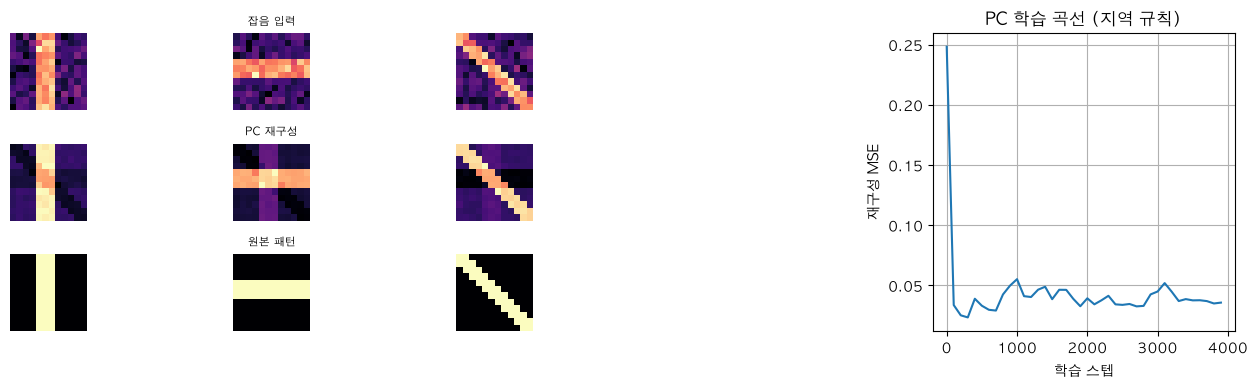

In [4]:
# (a) 재구성: 잡음 입력 -> PC 추론 -> 재구성   (b) 학습 곡선
xt, yt = gen(300, noise=0.15)
x1, e0, _ = infer(xt, W)
recon = (f(x1) @ W.t())

fig = plt.figure(figsize=(13, 4))
# 재구성 3x3
for k in range(K):
    idx = (yt==k).nonzero()[0].item()
    for r, (title, arr) in enumerate([("잡음 입력", xt[idx]), ("PC 재구성", recon[idx]), ("원본 패턴", PAT[k])]):
        ax = fig.add_subplot(3, 6, r*6 + k + 1)
        ax.imshow(arr.detach().reshape(g,g), cmap="magma"); ax.axis("off")
        if k==0: ax.set_ylabel(title, fontsize=9)
        ax.set_title(title if k==1 else "", fontsize=8)
# 학습곡선
ax2 = fig.add_subplot(1, 3, 3)
ax2.plot([m[0] for m in mse_hist], [m[1] for m in mse_hist], color="tab:blue")
ax2.set_xlabel("학습 스텝"); ax2.set_ylabel("재구성 MSE"); ax2.set_title("PC 학습 곡선 (지역 규칙)")
plt.tight_layout(); plt.show()

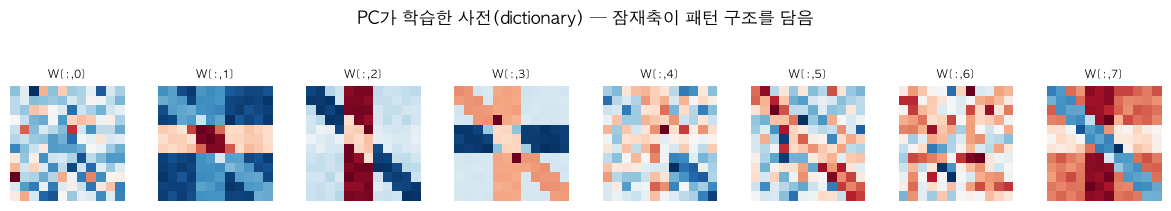

잠재코드 최근접평균 분류 정확도: 1.000  (라벨 없이 학습된 표현이 클래스를 구분!)


In [5]:
# (c) 학습된 사전(dictionary): W의 각 열  (d) 잠재코드가 클래스로 분리되나
fig, axes = plt.subplots(1, L, figsize=(12, 1.8))
for l in range(L):
    axes[l].imshow(W[:, l].reshape(g, g), cmap="RdBu_r"); axes[l].axis("off"); axes[l].set_title(f"W[:,{l}]", fontsize=8)
plt.suptitle("PC가 학습한 사전(dictionary) — 잠재축이 패턴 구조를 담음", y=1.15); plt.tight_layout(); plt.show()

means = torch.stack([x1[yt==k].mean(0) for k in range(K)])
pred = torch.cdist(x1, means).argmin(1)
print(f"잠재코드 최근접평균 분류 정확도: {(pred==yt).float().mean():.3f}  (라벨 없이 학습된 표현이 클래스를 구분!)")

## 3. 추론 = 에너지 하강 (예측 오차 최소화)

가중치를 고정하고 한 배치를 추론할 때, 스텝마다 에너지(예측 오차)가 **내려가는** 것을 봅니다. 이게 PC의 "지각(perception)" 과정 — 내부 표현을 굴려 세상을 설명하려는 것입니다.

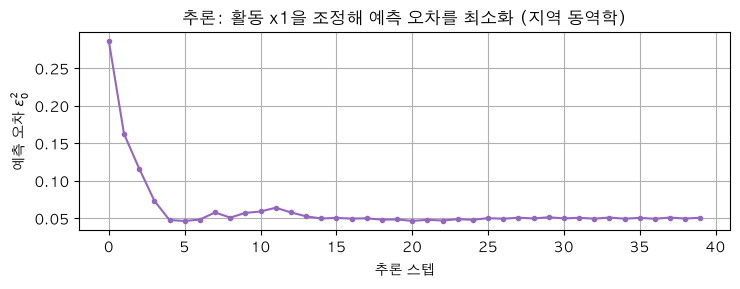

예측 오차: 0.286 -> 0.051 (x1=0에서 시작해 입력을 설명하며 하강)


In [6]:
xt, yt = gen(200, noise=0.2)
_, _, e_traj = infer(xt, W, n_steps=40, rec_energy=True)
fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(e_traj, marker="o", ms=3, color="tab:purple")
ax.set_xlabel("추론 스텝"); ax.set_ylabel(r"예측 오차 $\varepsilon_0^2$")
ax.set_title("추론: 활동 x1을 조정해 예측 오차를 최소화 (지역 동역학)")
plt.tight_layout(); plt.show()
print("예측 오차:", round(e_traj[0],3), "->", round(e_traj[-1],3), "(x1=0에서 시작해 입력을 설명하며 하강)")

## 4. PC → 스파이킹 → JEPA

### 4-1. PC를 스파이킹으로
PC의 두 노드는 스파이킹 뉴런으로 자연스럽게 대응됩니다:
- **값 노드 $x^{(l)}$** → 표현을 담는 뉴런 집단(발화율/막전위).
- **오차 노드 $\varepsilon^{(l)}$** → 예측과 실제의 차를 발화하는 별도 뉴런 집단.
- **추론 동역학** → 막전위 완화(relaxation)로, **헵 학습** → 앞 편들의 흔적 기반 지역 규칙으로.

(완전한 spiking PC는 연구 프론티어입니다 — 여기 rate 기반 PC가 그 골격입니다.)

### 4-2. PC ↔ JEPA는 사실 한 몸
| | Predictive Coding | JEPA |
|---|---|---|
| 예측 대상 | 아래 층의 **활동/표현** | 타깃 블록의 **latent 임베딩** |
| 목적 | 예측 오차 최소화 | latent 예측 오차 최소화 |
| 픽셀 복원? | 상위층은 안 함(표현 예측) | **안 함**(핵심) |
| 학습 | 지역 헵(오차×활동) | 보통 backprop (→ 여기를 PC/e-prop로 대체 가능) |

즉 **JEPA = 위계적 표현 예측**, PC도 **위계적 표현 예측**. JEPA의 backprop 학습을 **PC의 지역 규칙(또는 `04`의 e-prop)** 으로 갈아끼우면 → **BPTT 없는 뉴로모픽 JEPA**.

### 4-3. SNN-JEPA 아키텍처 스케치
```
관측 o_t  ──(SNN 인코더, spikegen 01편)──▶  표현 s_t
                                               │
                      (latent predictor)  ŝ_{t+k} = g(s_t, action)
                                               │
   타깃 o_{t+k} ─(EMA 타깃 SNN 인코더)─▶ s_{t+k}   ← stop-grad
                                               │
        예측 오차  ε = s_{t+k} − ŝ_{t+k}  ──▶  지역 학습(PC/e-prop)
                                               │
                      s_t 로 계획/제어 ──▶ PushT 행동
```
필요한 조각이 이 시리즈에 다 있습니다: **인코딩(`01`)·지역 가소성(`02`)·자격 흔적/보상(`03`)·학습 신호/e-prop(`04`)·예측 오차 표현학습(`05`)**.

> **기대치**: SNN-JEPA나 SNN에서의 grokking은 정립된 레시피가 아니라 **열린 연구 주제**입니다. 이 시리즈는 거기 필요한 재료와 직관을 갖추는 데까지가 목표입니다.

### 4-4. 다른 BPTT-free 지역 학습도 있음
- **Forward-Forward**(Hinton): 역방향 패스 없이 각 층이 "좋은/나쁜 데이터"의 goodness를 국소적으로 올리고/내림.

## 5. 정리 & 시리즈 1부 마무리

### 이번 편에서 배운 것
- **PC**: 위 층이 아래 층을 예측 → **예측 오차**가 활동(추론)과 가중치(학습)를 지역적으로 몬다. BPTT 없음.
- PC가 **비지도로 표현**을 학습(재구성 + 잠재코드가 클래스 분리).
- **PC ↔ JEPA는 개념적으로 한 몸** → PC/e-prop이 뉴로모픽 JEPA의 학습 엔진이 될 수 있다.

### 지금까지의 한 줄기
**흔적(trace)** 이 모든 편을 관통합니다:
`02` STDP 흔적(타이밍) → `03` 자격 흔적 × 보상 → `04` 자격 흔적 × 학습 신호(e-prop) → `05` 예측 오차. 세 번째 인자가 **타이밍 → 보상 → 뉴런별 오차 → 예측 오차**로 점점 정교해졌습니다.

### 이어서 해볼 만한 것
- **표준 task + grokking**: e-prop/PC로 실제 과제를 풀고, 지역 학습에서 grokking(지연된 일반화)이 나타나는지 실험.
- **SNN-JEPA**: 위 스케치를 조립해 예측 기반 표현·제어를 학습.